# Co-clustering method

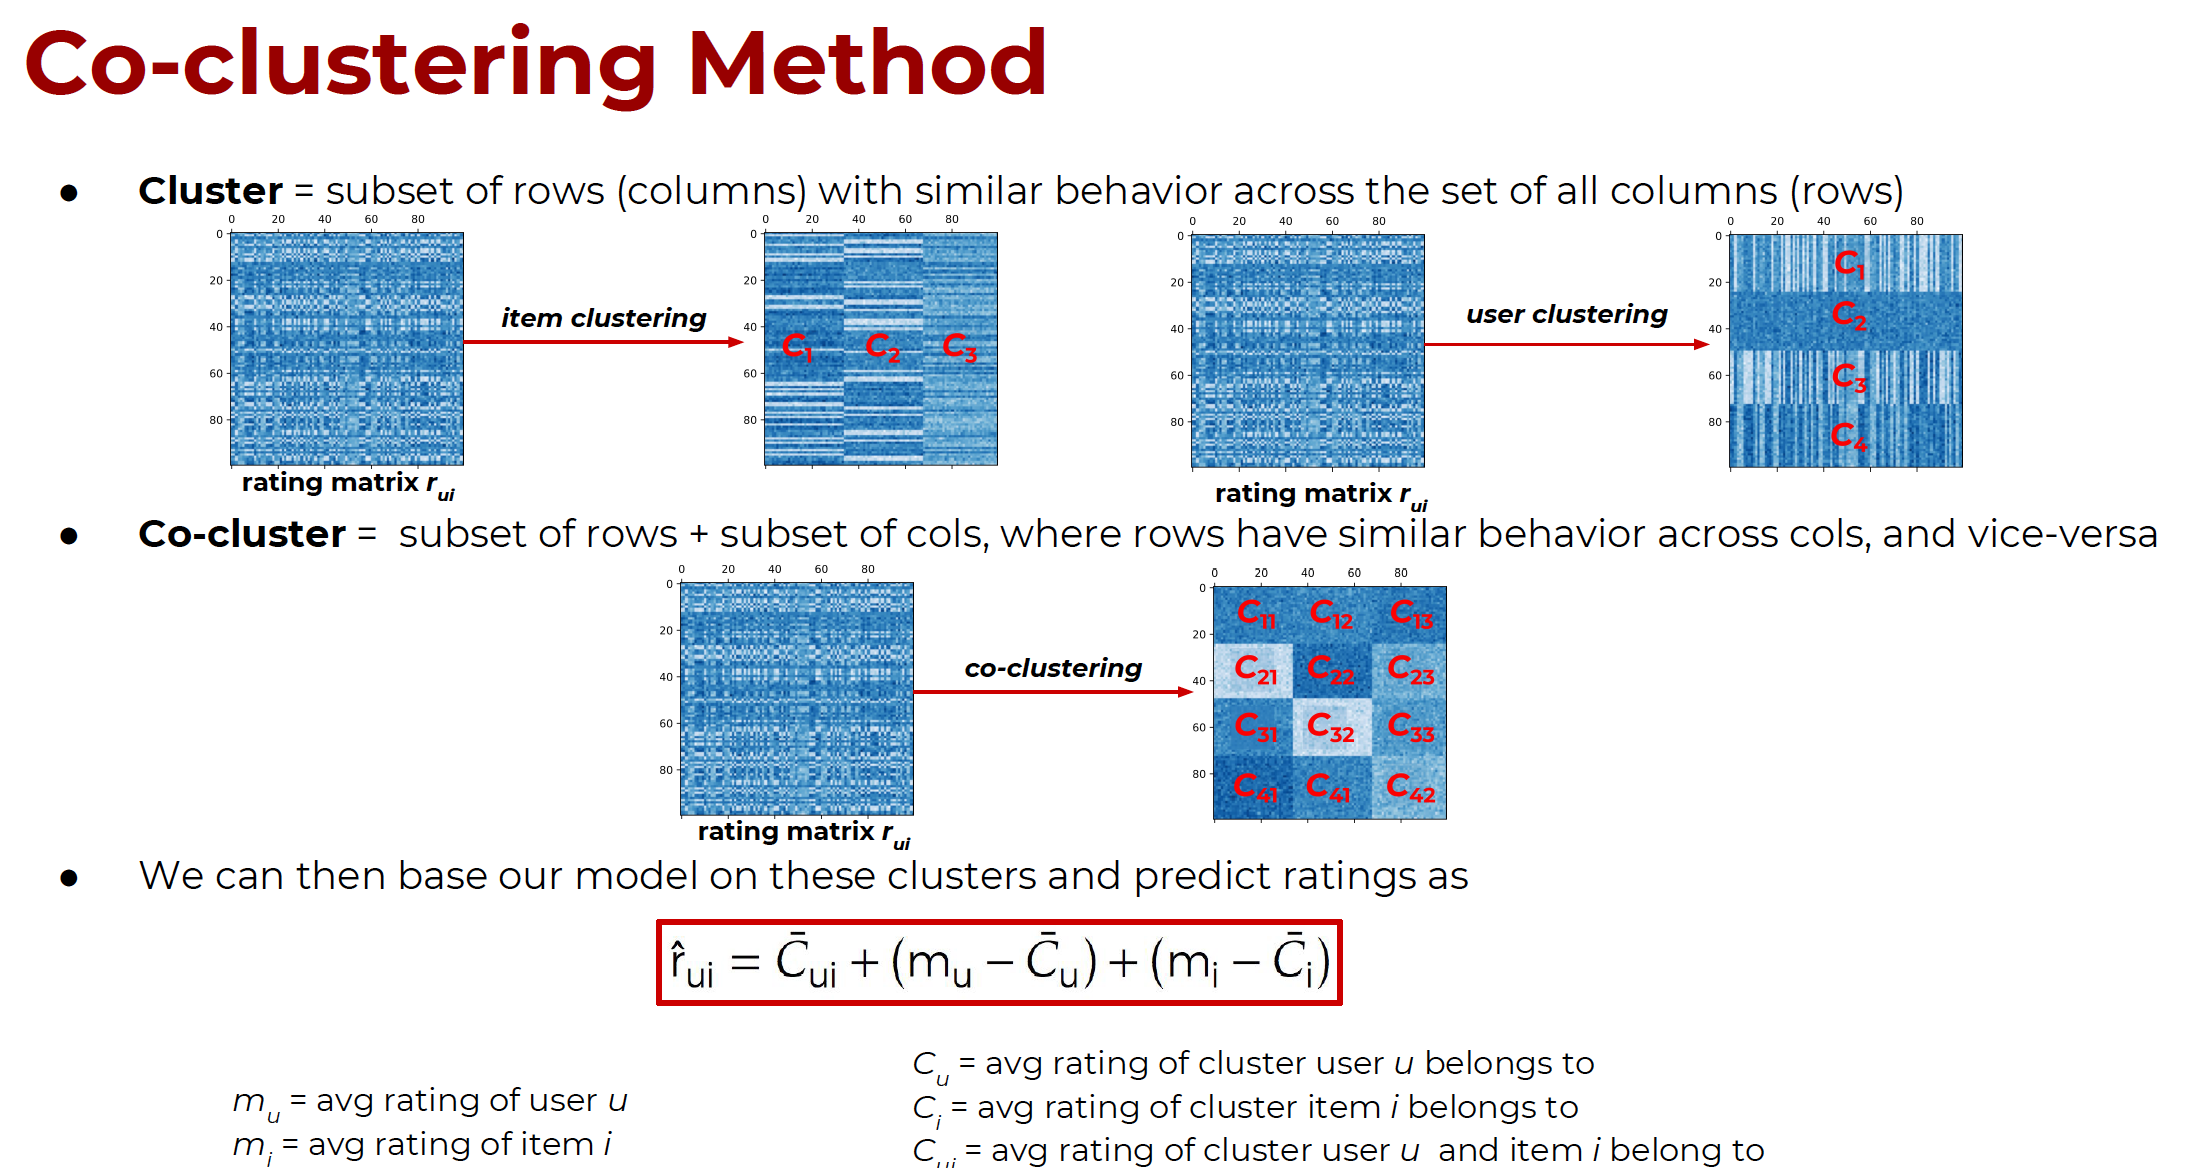

# Matrix Factorisation

There are different methods to matrix factorisation -

1. SVD(Singular Value Decomposition) - The most popular. Another variant is SVD++
2. NMF(Non Matrix Factoeisation)- Similar to SVD but the coefficients cannot be less than 0
3. Solving it as a linear regression problem using -
    1. Gradient Descent
    2. ALS (Alternating Least Squares)

In [1]:
import pandas as pd
import numpy as np

from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import SVD
from surprise import accuracy

from collections import defaultdict

In [2]:
df = pd.read_csv('../../datasets/booking/booking_train_set.csv.gz')

#### Create a number of days feature

`stay_days` will represent rating

In [3]:
df['checkout'] = pd.to_datetime(df['checkout'])
df['checkin'] = pd.to_datetime(df['checkin'])

df['stay_days'] = (df['checkout'] - df['checkin']).dt.days

In [4]:
ratings = df[['utrip_id','city_id','stay_days','checkin']]

#### Split data into train and test

In [5]:
ratings['rank_latest'] = ratings.groupby(['utrip_id'])['checkin'].rank(method='first', ascending=False)

train_ratings = ratings[ratings['rank_latest'] != 1]
test_ratings = ratings[ratings['rank_latest'] == 1]

<ipython-input-5-6cf6447f4ace>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings['rank_latest'] = ratings.groupby(['utrip_id'])['checkin'].rank(method='first', ascending=False)


In [6]:
print (ratings.shape,train_ratings.shape,test_ratings.shape )

(1166835, 5) (949149, 5) (217686, 5)


#### Convert the data into surprise format

In [7]:
train = train_ratings[['utrip_id','city_id','stay_days']]
train.columns=['user','item','rating']
train.index = pd.to_datetime(train_ratings['checkin'])

test = test_ratings[['utrip_id','city_id','stay_days']]
test.columns=['user','item','rating']
test.index = pd.to_datetime(test_ratings['checkin'])

In [8]:
rating_min, rating_max = min(df['stay_days']),max(df['stay_days'])

reader = Reader(line_format='user item rating timestamp', 
                sep=',',
                rating_scale = (rating_min,rating_max))

train_data = Dataset.load_from_df(train, reader=reader)
trainset = train_data.build_full_trainset()

#test_data = Dataset.load_from_df(test, reader=reader)
#testset = test_data.build_full_trainset()

# SVD

In [9]:
%%time

algo_svd = SVD()
algo_svd.fit(trainset) 

CPU times: user 41.1 s, sys: 106 ms, total: 41.2 s
Wall time: 41.3 s


Runs quite quickly on the whole dataset

#### Predicting for one user-item pair

In [39]:
prediction = algo_svd.predict('1006220_1', '31114')

In [40]:
prediction

Prediction(uid='1006220_1', iid='31114', r_ui=None, est=1.9281536486630306, details={'was_impossible': False})

#### Predicting for one user- all item pair

Create dataframe with 1 user and all possible items

In [23]:
item_cnt = len(train['item'].unique())

In [ ]:
udf = pd.DataFrame({'user':np.repeat('1006220_1', item_cnt),'item':train['item'].unique()})

Predict

In [34]:
def rating_pred(x):
    pred = algo_svd.predict(x.user, x.item)
    return pred.est

In [36]:
%%time
udf['pred'] = udf[['user','item']].apply(rating_pred,axis=1)

CPU times: user 17.7 s, sys: 715 ms, total: 18.4 s
Wall time: 17.7 s


Takes a lot of time for 1 user. Imagine for 200k users